## Portfolio Project: Predicting House Prices in Tashkent City

The objective of this project is to predict house prices in Tashkent City based on the given dataset.

In [ ]:
# Download dataset using Pandas library
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_data_08-02-2021.csv')
df.head()

,location,district,rooms,size,level,max_levels,price
0,"город Ташкент, Юнусабадский район, Юнусабад 8-...",Юнусабадский,3,57,4,4,52000
1,"город Ташкент, Яккасарайский район, 1-й тупик ...",Яккасарайский,2,52,4,5,56000
2,"город Ташкент, Чиланзарский район, Чиланзар 2-...",Чиланзарский,2,42,4,4,37000
3,"город Ташкент, Чиланзарский район, Чиланзар 9-...",Чиланзарский,3,65,1,4,49500
4,"город Ташкент, Чиланзарский район, площадь Актепа",Чиланзарский,3,70,3,5,55000


### Column Descriptions
- `location` - location of the selling house
- `district` - district(part of the city) of the house
- `rooms` - the number of rooms
- `size` - size of the house(kv.m)
- `level` - in which floor the house is located
- `max_levels` - overall number of floors in the building
- `price` - the price of the house

### We will complete this project using the CRISP-DM methodology.

### Understanding the Process

#### Questions for the Client

1. **Question:** Where will the model be used?  
   **Answer:** The model will be used as a component of a larger system.

2. **Question:** How are house prices currently determined?  
   **Answer:** They are estimated by human experts.

3. **Question:** What is the accuracy of the current approach?  
   **Answer:** Approximately 20%.


### Analytical Approach

- **Question:** Which type of machine learning should we use?  
- **Answer:** Since both the problem and the target labels are provided, we will use **Supervised Learning**.

- **Question:** What type of problem (algorithm) is this?  
- **Answer:** The goal is to predict house prices, which are continuous numerical values. Therefore, we will use a **Regression** algorithm.

- **Question:** Which learning approach should we use?  
- **Answer:** Since the data is static and does not arrive as a continuous stream, we will use an **Offline Learning** approach.

Model performance will be evaluated using RMSE and Cross-Validation.

### Data Understanding

In [2]:
# Import the required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [3]:
# Print the first 5 rows from dataframe
df.head()

,location,district,rooms,size,level,max_levels,price
0,"город Ташкент, Юнусабадский район, Юнусабад 8-...",Юнусабадский,3,57,4,4,52000
1,"город Ташкент, Яккасарайский район, 1-й тупик ...",Яккасарайский,2,52,4,5,56000
2,"город Ташкент, Чиланзарский район, Чиланзар 2-...",Чиланзарский,2,42,4,4,37000
3,"город Ташкент, Чиланзарский район, Чиланзар 9-...",Чиланзарский,3,65,1,4,49500
4,"город Ташкент, Чиланзарский район, площадь Актепа",Чиланзарский,3,70,3,5,55000


In [4]:
# Checking the shape of the DF
df.shape

(7565, 7)

In [5]:
# Other information about DF
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   location    7565 non-null   object
 1   district    7565 non-null   object
 2   rooms       7565 non-null   int64 
 3   size        7565 non-null   object
 4   level       7565 non-null   int64 
 5   max_levels  7565 non-null   int64 
 6   price       7565 non-null   object
dtypes: int64(3), object(4)
memory usage: 413.8+ KB


The dataset contains a total of 7,565 rows and has no missing (NaN) values. However, the data types of the **size** and **price** columns should be converted from **object** to **float**.

In [6]:
# Before changing the data types, let's inspect the columns we want to convert.

pd.to_numeric(df["size"], errors="coerce").notna().all()

np.False_

In [7]:
# If the result is False, it means the column contains at least one non-numeric value. Let's inspect the second column.

pd.to_numeric(df["price"], errors="coerce").notna().all()

np.False_

In [8]:
# Now, let's convert the data types of both columns and replace any non-numeric values with NaN.

df["size"] = pd.to_numeric(df["size"], errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [9]:
# Let's check the number of NaN values
df[df["size"].isna()]

,location,district,rooms,size,level,max_levels,price
5347,"город Ташкент, Яшнободский район, Дархон",Яшнободский,4,NaN,3,5,150000.0


In [10]:
df[df["price"].isna()]

,location,district,rooms,size,level,max_levels,price
202,"город Ташкент, Яккасарайский район, Баходыра",Яккасарайский,3,119.0,3,9,NaN
411,"город Ташкент, Яккасарайский район, Баходыра",Яккасарайский,4,160.0,4,9,NaN
439,"город Ташкент, Мирзо-Улугбекский район, улица ...",Мирзо-Улугбекский,3,105.0,5,6,NaN
460,"город Ташкент, Чиланзарский район, Чиланзар 1-...",Чиланзарский,3,90.0,6,8,NaN
507,"город Ташкент, Яшнободский район, 1-й проезд А...",Яшнободский,2,48.0,4,4,NaN
...,...,...,...,...,...,...,...
7039,"город Ташкент, Яшнободский район, Городок Авиа...",Яшнободский,1,38.7,3,8,NaN
7196,"город Ташкент, Чиланзарский район, Чиланзар-16",Чиланзарский,2,51.0,3,4,NaN
7323,"город Ташкент, Мирзо-Улугбекский район, жилой ...",Мирзо-Улугбекский,6,208.0,1,7,NaN
7403,"город Ташкент, Учтепинский район, Чиланзар 14-...",Учтепинский,2,35.0,2,9,NaN


The **size** column contains one missing (NaN) value, so we will simply remove that row. However, the **price** column contains 99 missing values. Since **price** is the target label, we cannot impute these values.

In [11]:
# Drop NaN values
df = df.dropna(subset=["price", "size"])

In [12]:
# Checking
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7465 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    7465 non-null   object 
 1   district    7465 non-null   object 
 2   rooms       7465 non-null   int64  
 3   size        7465 non-null   float64
 4   level       7465 non-null   int64  
 5   max_levels  7465 non-null   int64  
 6   price       7465 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 466.6+ KB


In [13]:
# Exploring object data dtype columns

df["location"].value_counts()

,count
location,
"город Ташкент, Чиланзарский район, Чиланзар",112
"город Ташкент, Яккасарайский район, Кушбеги",110
"город Ташкент, Мирзо-Улугбекский район, Буюк Ипак Йули",87
"город Ташкент, Яккасарайский район, Бабура",82
"город Ташкент, Учтепинский район, Чиланзар 24-й квартал",79
...,...
"город Ташкент, Чиланзарский район, Chil 20",1
"город Ташкент, Чиланзарский район, Чиланзар Д20-18-82",1
"город Ташкент, Олмазорский район, Нозимахоним",1


In [ ]:
df["district"].value_counts()

,count
district,
Чиланзарский,1631
Мирзо-Улугбекский,1368
Юнусабадский,877
Учтепинский,875
Мирабадский,772
Яккасарайский,650
Яшнободский,468
Шайхантахурский,374
Олмазорский,267


The **location** column contains a large number of unique values, while the **district** column has only 12 categories. Since both columns provide information about the property's location, we can drop the **location** column. Encoding a high-cardinality feature like **location** could negatively impact the model's performance.

In [14]:
# Drop "location" column
df = df.drop(columns=["location"])

In [15]:
df.describe()

,rooms,size,level,max_levels,price
count,7465.000000,7465.000000,7465.000000,7465.000000,7.465000e+03
mean,2.622103,113.537018,3.693771,6.023979,7.132367e+04
std,1.083155,1501.157996,2.236905,2.607103,6.405659e+05
min,1.000000,1.000000,1.000000,1.000000,2.000000e+00
25%,2.000000,50.000000,2.000000,4.000000,3.500000e+04
50%,3.000000,65.000000,3.000000,5.000000,4.650000e+04
75%,3.000000,85.000000,5.000000,9.000000,6.700000e+04
max,10.000000,70000.000000,19.000000,25.000000,5.200000e+07


We will review and correct the minimum and maximum values for each column individually.

In [16]:
# ROOMS

In [17]:
df["rooms"].value_counts()

,count
rooms,
2,2717
3,2308
4,1123
1,993
5,257
6,44
7,12
8,6
10,5


In [ ]:
#We will exclude rows where the **rooms** value exceeds 5, as there are too few such observations to be useful for training the model.
df = df.drop(df[df["rooms"]>5].index , axis=0)

In [18]:
# SIZE

In [19]:
#We will also exclude houses with an area smaller than **12 m²** or larger than **100 m²**, as these represent extreme values that are not relevant to our analysis.
df = df.drop(df[(df["size"] > 100) | (df["size"] < 12)].index, axis=0)

In [20]:
# LEVEL

In [21]:
#We will also remove rows where the **floor** value is greater than **8**.
df = df.drop(df[df["level"]>8].index , axis=0)

In [22]:
# MAX_LEVELS

In [23]:
#We will also limit the **max_floor** value to **12**, removing rows that exceed this limit.
df = df.drop(df[df["max_levels"]>12].index , axis=0)

In [24]:
# PRICE

In [25]:
#We will also limit the **price** column to values between **20,000** and **100,000**, removing rows outside this range.
df = df.drop(df[(df["price"]>100000) | (df["price"]<20000)].index , axis=0)

In [26]:
df.describe()

,rooms,size,level,max_levels,price
count,5867.000000,5867.000000,5867.000000,5867.000000,5867.000000
mean,2.393557,62.197532,3.332027,5.534345,46147.470939
std,0.874135,17.765255,1.747201,2.154524,16900.674244
min,1.000000,15.000000,1.000000,1.000000,20000.000000
25%,2.000000,49.470000,2.000000,4.000000,33999.500000
50%,2.000000,60.000000,3.000000,5.000000,42000.000000
75%,3.000000,75.000000,4.000000,7.000000,55500.000000
max,5.000000,100.000000,8.000000,12.000000,100000.000000


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5867 entries, 0 to 7564
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   district    5867 non-null   object 
 1   rooms       5867 non-null   int64  
 2   size        5867 non-null   float64
 3   level       5867 non-null   int64  
 4   max_levels  5867 non-null   int64  
 5   price       5867 non-null   float64
dtypes: float64(2), int64(3), object(1)
memory usage: 320.9+ KB


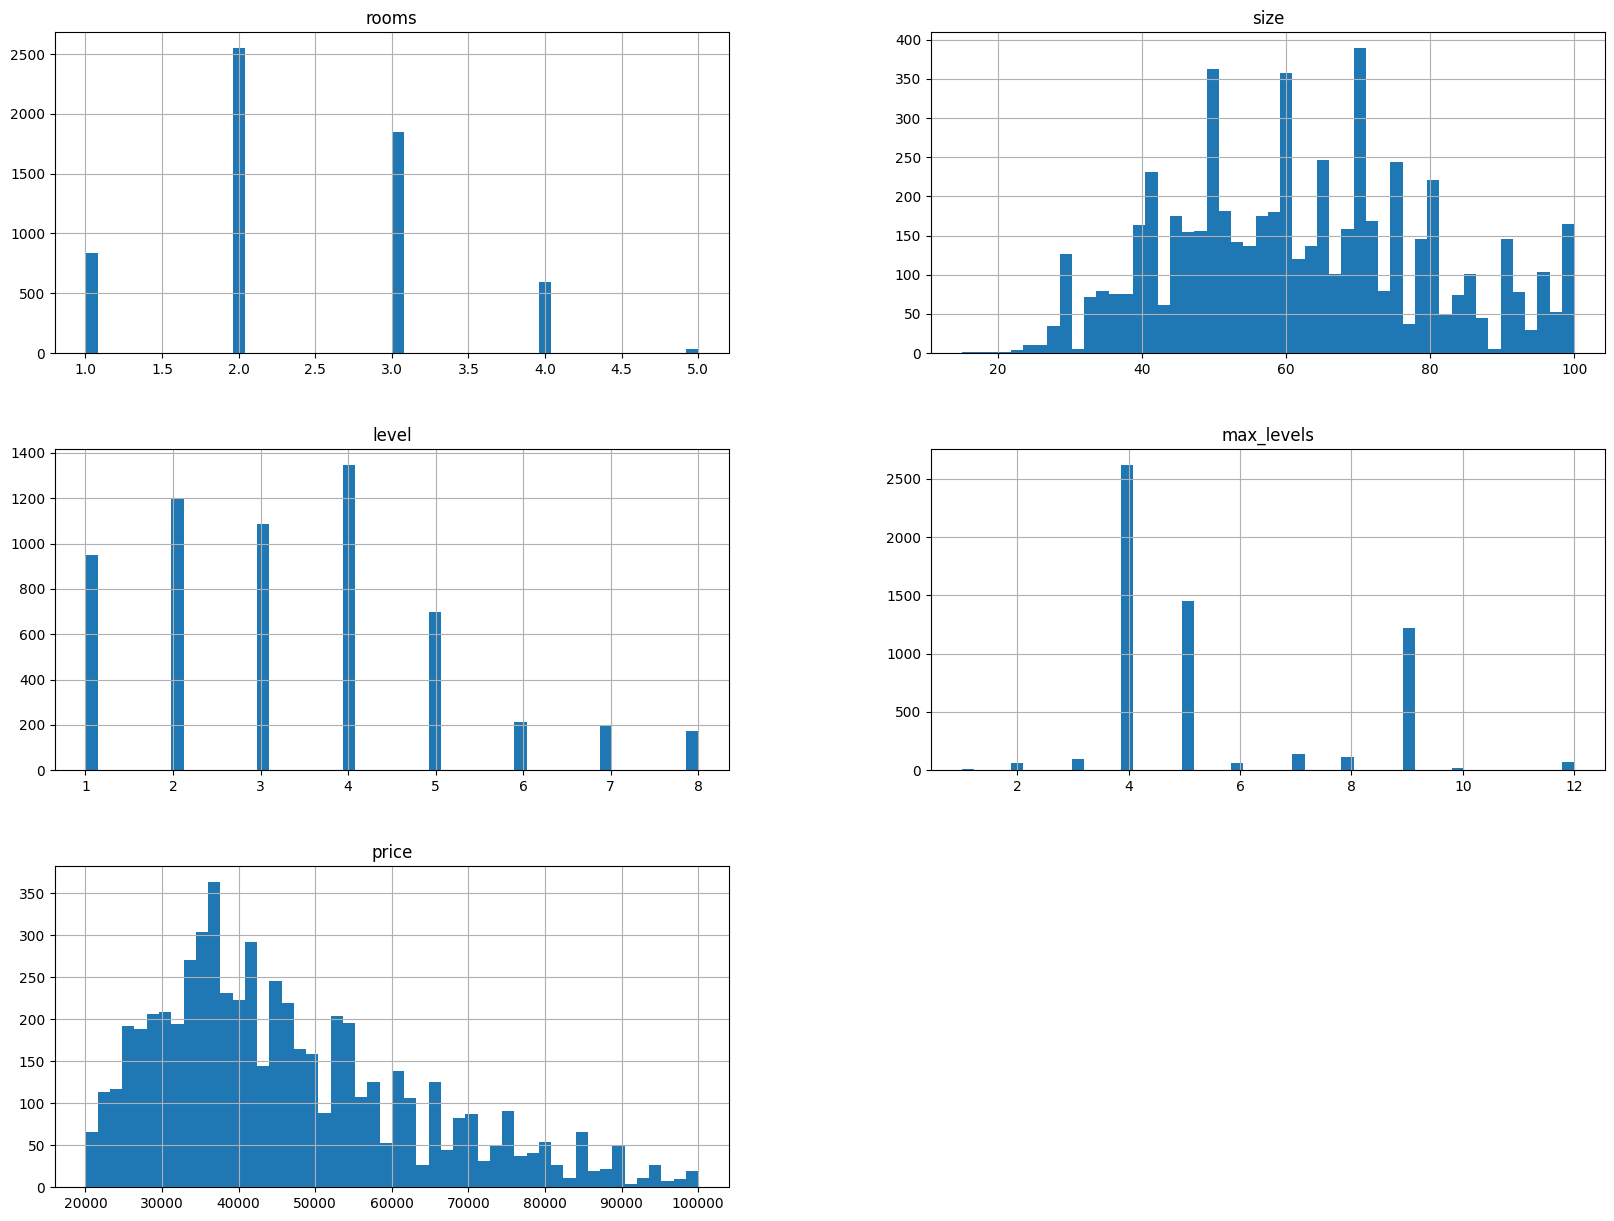

In [28]:
# Graphs

df.hist(bins=50, figsize=(20,15))
plt.show()

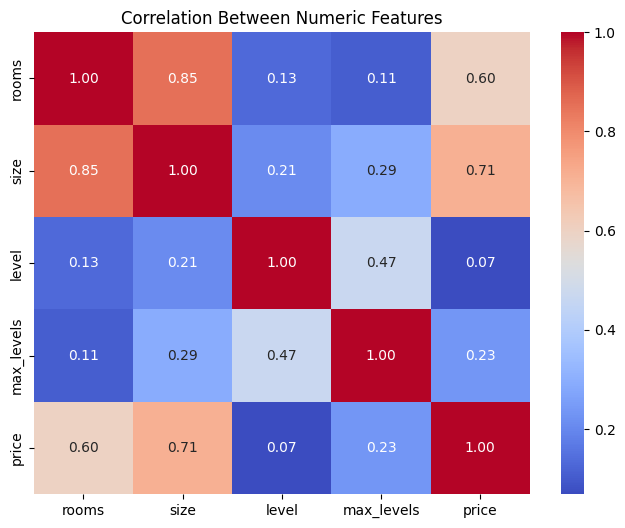

In [29]:
# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.show()

In [30]:
# Correlation

In [31]:
df.corr(numeric_only=True)

,rooms,size,level,max_levels,price
rooms,1.000000,0.852356,0.133870,0.106465,0.597675
size,0.852356,1.000000,0.207569,0.292626,0.712385
level,0.133870,0.207569,1.000000,0.465861,0.068711
max_levels,0.106465,0.292626,0.465861,1.000000,0.233830
price,0.597675,0.712385,0.068711,0.233830,1.000000


In [33]:
# Let's print it in more understandable way
df.corrwith(df["price"], numeric_only=True).sort_values(ascending=False)

,0
price,1.000000
size,0.712385
rooms,0.597675
max_levels,0.233830
level,0.068711


Feature Engineering

In [34]:
# Automize adding new columns

from sklearn.base import BaseEstimator, TransformerMixin

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
  def __init__(self):
    return None
  def fit(self, X, y=None):
    return self # our function is only a transformer and not estimator!
  def transform(self, X):
    size_per_room = X["size"] / X["rooms"]
    floor_ratio = X["level"] / X["max_levels"]
    return X.assign(size_per_room=size_per_room, floor_ratio=floor_ratio)

In [35]:
# Apply our new function
df2 = CombinedAttributesAdder().fit_transform(df)

In [36]:
df2.corrwith(df["price"], numeric_only=True).sort_values(ascending=False)

,0
price,1.000000
size,0.712385
rooms,0.597675
max_levels,0.233830
level,0.068711
floor_ratio,-0.096206
size_per_room,-0.134800


###Machine Learning Preparation

In [37]:
# Train va Test split

from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=22)

In [38]:
# Let's make a copy of our original train_set
houses = train_set.copy()

In [39]:
houses.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4693 entries, 5837 to 3834
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   district    4693 non-null   object 
 1   rooms       4693 non-null   int64  
 2   size        4693 non-null   float64
 3   level       4693 non-null   int64  
 4   max_levels  4693 non-null   int64  
 5   price       4693 non-null   float64
dtypes: float64(2), int64(3), object(1)
memory usage: 256.6+ KB


Dataset preparing

In [40]:
# Split the dataset to X and Y
X_set = houses.drop("price", axis=1)
y = houses["price"].copy()

X_num = X_set.drop("district", axis=1)

Import all the transformers we will need from sklearn library to build our Pipeline

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_pipeline = Pipeline([
    ("attribs_adder", CombinedAttributesAdder()),
    ("std_scaler", StandardScaler())
])

In [42]:
# Import ColumnTransformer to gather all work in one
from sklearn.compose import ColumnTransformer

num_attribs = list(X_num)
cat_attribs = ["district"]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs)
])

In [43]:
# Now we can get our prepared train data through our Pipeline

X_prepared = full_pipeline.fit_transform(X_set)

In [44]:
#Checking
X_prepared

array([[-0.44445281, -0.39974927,  0.37992125, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44445281, -0.17486069, -1.35111801, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44445281, -0.11863855,  0.95693434, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.44445281, -0.00619426,  2.6879736 , ...,  1.        ,
         0.        ,  0.        ],
       [ 0.69971451,  0.05002788,  0.37992125, ...,  0.        ,
         0.        ,  0.        ],
       [-1.58862012,  0.4435829 ,  1.53394742, ...,  0.        ,
         0.        ,  0.        ]])

###Machine Learning

In [45]:
# Linear Regression

In [46]:
from sklearn.linear_model import LinearRegression

LR_model = LinearRegression()

In [47]:
#Training the model
LR_model.fit(X_prepared, y)

LinearRegression()

###Evaluation

In [48]:
#Checking the test data
test_set

,district,rooms,size,level,max_levels,price
3829,Мирзо-Улугбекский,4,100.0,2,4,95000.0
6155,Мирзо-Улугбекский,3,56.0,5,5,50000.0
2361,Юнусабадский,2,63.0,3,4,45000.0
2385,Мирабадский,3,100.0,7,9,90000.0
3100,Мирзо-Улугбекский,2,53.0,5,5,37000.0
...,...,...,...,...,...,...
5007,Мирзо-Улугбекский,3,75.0,7,9,46500.0
1375,Чиланзарский,5,92.0,5,5,50000.0
5442,Чиланзарский,3,65.0,1,4,45500.0
2943,Юнусабадский,3,70.0,4,4,46200.0


In [49]:
# Seperating the target(Y) and X data
X_test_set = test_set.drop("price", axis=1)
X_test_set

,district,rooms,size,level,max_levels
3829,Мирзо-Улугбекский,4,100.0,2,4
6155,Мирзо-Улугбекский,3,56.0,5,5
2361,Юнусабадский,2,63.0,3,4
2385,Мирабадский,3,100.0,7,9
3100,Мирзо-Улугбекский,2,53.0,5,5
...,...,...,...,...,...
5007,Мирзо-Улугбекский,3,75.0,7,9
1375,Чиланзарский,5,92.0,5,5
5442,Чиланзарский,3,65.0,1,4
2943,Юнусабадский,3,70.0,4,4


In [50]:
y_test_set = test_set["price"].copy()

In [51]:
#Checking
y_test_set

,price
3829,95000.0
6155,50000.0
2361,45000.0
2385,90000.0
3100,37000.0
...,...
5007,46500.0
1375,50000.0
5442,45500.0
2943,46200.0


In [52]:
#Channeling the test data through the Pipeline
X_test_prepared = full_pipeline.transform(X_test_set)

In [53]:
# Getting prediction from our model
y_predicted = LR_model.predict(X_test_prepared)

Now let's compare the real target and predicted values

In [54]:
# Import metrics for our evaluation
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test_set, y_predicted)
print("RootMeanSquareError:", np.sqrt(mse))

RootMeanSquareError: 10617.79814210783


##Now let's try another model

In [55]:
# Random Forest Regressor

In [56]:
# Import the model
from sklearn.ensemble import RandomForestRegressor
RF_model = RandomForestRegressor()
RF_model.fit(X_prepared, y)

RandomForestRegressor()

In [57]:
# Get predictions from our RF model
y_predicted_RF = RF_model.predict(X_test_prepared)

In [58]:
# Let's check the result
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test_set, y_predicted_RF)
print("RootMeanSquareError:", np.sqrt(mse))

RootMeanSquareError: 9603.140996535376


###Cross Validation (Better check)

In [59]:
# We get new X and Y for this
X = df.drop("price", axis=1)
y = df["price"].copy()

In [64]:
# Let's create a new Pipeline for our Cross-Validation with the model Linear Regression
full_pipeline_cross = Pipeline([
    ("preprocessor", full_pipeline),
    ("regressor", LinearRegression())
])

In [65]:
#Import and get the results
from sklearn.model_selection import cross_val_score
mse_scores = cross_val_score(full_pipeline_cross ,X, y, cv=10, scoring="neg_mean_squared_error")

In [66]:
# Print result
def show_scores(scores):
  print("Scores", scores)
  print("Mean:", scores.mean())
  print("Std.dev:", scores.std())

In [67]:
# Cross-val results of LR model
show_scores(np.sqrt(-mse_scores))

Scores [10316.24727777 10100.20975269 12538.39289608 12506.17975287
 11243.9230938  11227.16168854  9596.42171505 10539.02648608
 10514.66331637 10509.57574701]
Mean: 10909.1801726261
Std.dev: 927.3394820609727


In [68]:
# Cross-val pipeline of Random Forest Regressor
full_pipeline_random = Pipeline([
    ("preprocessor", full_pipeline),
    ("random", RandomForestRegressor())
])

In [69]:
# Cross-val results of RF model
RF_scores = cross_val_score(full_pipeline_random,X, y, cv=10, scoring="neg_mean_squared_error")
RF_rmse_scores = np.sqrt(-RF_scores)
show_scores(RF_rmse_scores)

Scores [ 8797.38778354  9277.31193295 11224.90516766 11203.24753255
 10404.72549283  9757.39856603  9083.32167501  9445.899755
  9291.68339079  9790.80804641]
Mean: 9827.668934275453
Std.dev: 808.4076708748779


##In this project we tried to train Linear Regression and Random Forest Regression algorithmic models and after checking the results of both models with varius evaluations , the Random Forest model showed the highest performance.

##To increase the model's performance we need more data and technical support for running the model on.

###Saving the model

In [70]:
# We are gonna use the pickle library to save our model and assigned the name to "LR_model.pkl"
import pickle

filename = "LR_model.pkl"
with open(filename, "wb") as file:
  pickle.dump(LR_model, file)

In [71]:
# Checking the file with reopening it here
with open(filename, "rb") as file:
  model = pickle.load(file)

In [72]:
# Lets save our best model with another file type and call it "RF_model.jbl"
import joblib

filename = "RF_model.jbl"
joblib.dump(RF_model, filename)

['RF_model.jbl']

### All models are saved successfully and ready to be the part of the original product